# Project 11 — Eight Schools (hierarchical normal): centered vs non-centered + the funnel

**Tier 3 · Multilevel** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P11_eight-schools/P11_eight-schools_12-06-2026_Opus48.ipynb)

The canonical **hierarchical model** (Rubin 1981): 8 schools, each with a noisy estimate of a coaching
effect. This is a **deliberate-failure project**. We first fit the textbook **centered** parameterization
and watch the sampler break in the *funnel* (divergences pile up where `tau` is small). We diagnose it
with `az.plot_pair` colored by divergence, then **fix** it with the **non-centered** parameterization —
the divergences vanish and ESS jumps. Same model, different geometry: a pure *computation* lesson.
We add **Simulation-Based Calibration (SBC)** to prove the fixed sampler is calibrated.

## Learning objectives
1. Build the hierarchical normal `theta_j ~ Normal(mu, tau)`, `y_j ~ Normal(theta_j, sigma_j)`.
2. **Reproduce a real sampling failure**: divergences in the centered funnel; visualize it with `plot_pair`.
3. **Fix it** with the non-centered reparameterization `theta = mu + tau·z`, `z ~ Normal(0,1)`.
4. Run **SBC** on `mu` and confirm the rank histogram is ~uniform (calibrated).

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
trapz = getattr(np, "trapezoid", None) or np.trapz
RANDOM_SEED = 11
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Data — Rubin (1981) eight schools [hardcoded]
The eight schools' estimated coaching effects `y` (points on the SAT-V) and their standard errors `sigma`.

In [2]:
y = np.array([28., 8., -3., 7., -1., 1., 18., 12.])
sigma = np.array([15., 10., 16., 11., 9., 11., 10., 18.])
J = len(y)
schools = pd.DataFrame({"school": list("ABCDEFGH"), "y": y, "sigma": sigma})
print(schools.to_string(index=False))
print(f"\nJ = {J} schools | pooled (precision-weighted) mean = {np.sum(y/sigma**2)/np.sum(1/sigma**2):.2f}")

school    y  sigma
     A 28.0   15.0
     B  8.0   10.0
     C -3.0   16.0
     D  7.0   11.0
     E -1.0    9.0
     F  1.0   11.0
     G 18.0   10.0
     H 12.0   18.0

J = 8 schools | pooled (precision-weighted) mean = 7.69


## Stage 0 — Fake-data parameter recovery [required] (non-centered model)
Simulate from known `mu = 6, tau = 5`; draw true `theta_j`, then noisy `y_j`; fit the **non-centered**
model and confirm `mu`, `tau` land in the 90% HDI.

In [3]:
mu_t, tau_t = 6.0, 5.0
theta_t = rng.normal(mu_t, tau_t, J)
y_sim = rng.normal(theta_t, sigma)
with pm.Model() as m0:
    mu = pm.Normal("mu", 0, 10); tau = pm.HalfNormal("tau", 10)
    z = pm.Normal("z", 0, 1, shape=J)
    theta = pm.Deterministic("theta", mu + tau*z)
    pm.Normal("y", theta, sigma, observed=y_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.95,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, var_names=["mu","tau"], hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for name,tr in [("mu",mu_t),("tau",tau_t)]:
    print(name, "recovered:", bool(s0.loc[name,"hdi_5%"] <= tr <= s0.loc[name,"hdi_95%"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu, tau, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


      mean  hdi_5%  hdi_95%  r_hat  ess_bulk
mu   6.042  -0.614   13.269    1.0    4061.0
tau  4.936   0.000   10.271    1.0    1587.0
mu recovered: True
tau recovered: True


## Stage 1–2 — Question & EDA
**Question:** is there a real coaching effect, and how much should each school's noisy estimate be
**shrunk** toward the common mean `mu`? The key hyperparameter is `tau`, the between-school SD: `tau→0`
means complete pooling (all schools share one effect); large `tau` means no pooling.

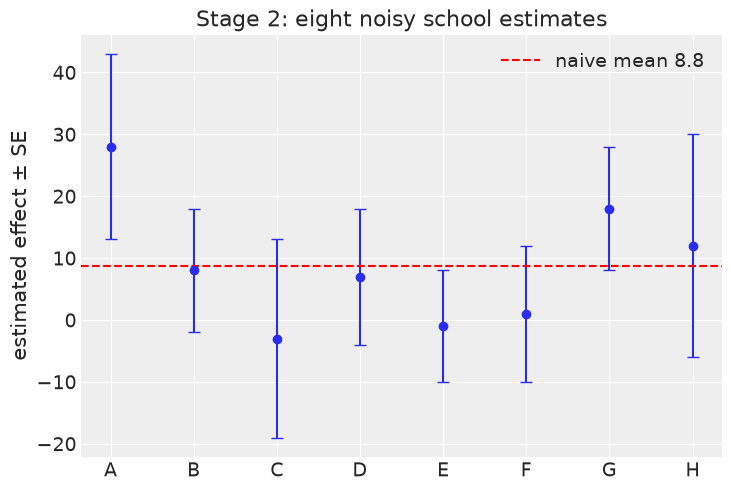

Estimates range from -3 to 28 but every interval overlaps the others — much could be noise.


In [4]:
plt.errorbar(np.arange(J), y, yerr=sigma, fmt="o", capsize=4)
plt.axhline(y.mean(), color="r", ls="--", label=f"naive mean {y.mean():.1f}")
plt.xticks(np.arange(J), list("ABCDEFGH")); plt.ylabel("estimated effect ± SE")
plt.title("Stage 2: eight noisy school estimates"); plt.legend(); plt.show()
print("Estimates range from -3 to 28 but every interval overlaps the others — much could be noise.")

## Stage 3 — Model specification
$$y_j \sim \mathrm{Normal}(\theta_j, \sigma_j),\quad \theta_j \sim \mathrm{Normal}(\mu, \tau),$$
$$\mu \sim \mathrm{Normal}(0, 10),\quad \tau \sim \mathrm{HalfNormal}(10).$$
**Centered** parameterization samples `theta_j` directly. When `tau` is small the joint `(theta_j, tau)`
forms a sharp *funnel* that Hamiltonian Monte Carlo cannot traverse with a single step size → divergences.

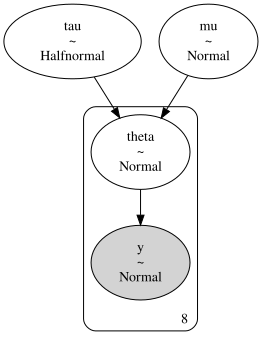

In [5]:
with pm.Model() as model_c:
    mu = pm.Normal("mu", 0, 10)
    tau = pm.HalfNormal("tau", 10)
    theta = pm.Normal("theta", mu, tau, shape=J)     # CENTERED
    pm.Normal("y", theta, sigma, observed=y)
try:
    display(pm.model_to_graphviz(model_c))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| DAG: mu,tau -> theta -> y")

## Stage 4 — Prior predictive on the OUTCOME scale
Push the priors through to simulated school estimates `y` and confirm the implied effects are plausible
(tens of points, not thousands).

Sampling: [mu, tau, theta, y]


prior predictive y: mean 0.2, sd 18.8, 1-99% [-46, 47]


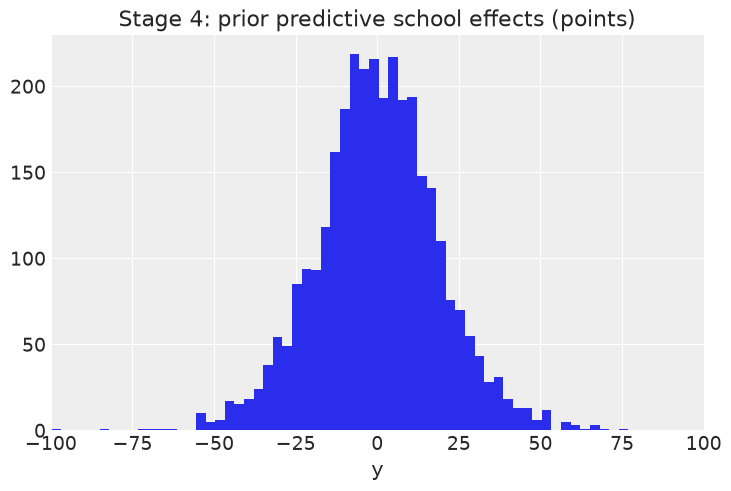

In [6]:
with model_c:
    pp = pm.sample_prior_predictive(samples=400, random_seed=RANDOM_SEED)
ysim = pp.prior_predictive["y"].values.reshape(-1)
print(f"prior predictive y: mean {ysim.mean():.1f}, sd {ysim.std():.1f}, "
      f"1-99% [{np.percentile(ysim,1):.0f}, {np.percentile(ysim,99):.0f}]")
plt.hist(ysim, bins=60); plt.xlim(-100,100)
plt.title("Stage 4: prior predictive school effects (points)"); plt.xlabel("y"); plt.show()

## Stage 5 — Fit the CENTERED model (expected to FAIL)
We deliberately sample the centered model. Watch the divergence count.

In [7]:
t0=time.time()
with model_c:
    idata_c = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                        random_seed=RANDOM_SEED, progressbar=False,
                        idata_kwargs={"log_likelihood": True})
div_c = int(idata_c.sample_stats.diverging.values.sum())
print(f"wall-clock {time.time()-t0:.1f}s | CENTERED divergences: {div_c}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu, tau, theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


There were 129 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


wall-clock 13.7s | CENTERED divergences: 129


## Stage 6 — Diagnostics of the CENTERED model: the failure
Low ESS on `tau`, R̂ above target, and **many divergences** — all symptoms of the funnel.

In [8]:
sc = az.summary(idata_c, var_names=["mu","tau"], hdi_prob=0.94)
print(sc[["mean","sd","r_hat","ess_bulk","ess_tail"]])
print(f"\nCENTERED divergences: {div_c} | min ESS-bulk(tau): {sc.loc['tau','ess_bulk']:.0f}")
print("Symptoms: divergences > 0, tau ESS low, r_hat possibly > 1.01 — the centered funnel.")

      mean     sd  r_hat  ess_bulk  ess_tail
mu   6.613  4.212   1.00     651.0     648.0
tau  5.294  3.473   1.02     215.0     140.0

CENTERED divergences: 129 | min ESS-bulk(tau): 215
Symptoms: divergences > 0, tau ESS low, r_hat possibly > 1.01 — the centered funnel.


## Stage 6b — VISUALIZE the funnel (plot_pair colored by divergence)
The classic diagnostic: `mu`/`theta[0]` vs `log(tau)`. Divergent transitions (highlighted) cluster in the
narrow neck of the funnel where `tau → 0` — exactly where HMC stalls.

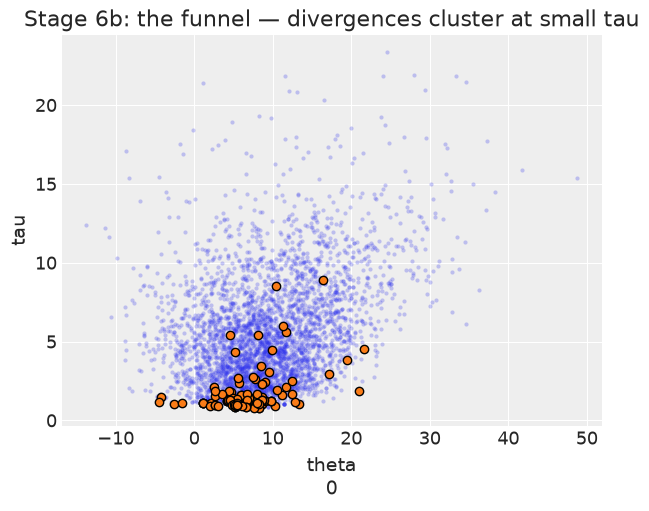

divergent draws sit at median log(tau) = 0.22 vs non-divergent 1.55 — divergences live in the neck.


In [9]:
az.plot_pair(idata_c, var_names=["theta", "tau"], coords={"theta_dim_0":[0]},
             divergences=True, figsize=(6,5),
             scatter_kwargs={"alpha":0.25})
plt.title("Stage 6b: the funnel — divergences cluster at small tau"); plt.show()
log_tau = np.log(idata_c.posterior["tau"].values.ravel())
div_mask = idata_c.sample_stats.diverging.values.ravel()
if div_mask.sum() > 0:
    print(f"divergent draws sit at median log(tau) = {np.median(log_tau[div_mask]):.2f} "
          f"vs non-divergent {np.median(log_tau[~div_mask]):.2f} — divergences live in the neck.")

## Stage 5-fix / Stage 6-fix — the NON-CENTERED reparameterization (the FIX)
Write `theta_j = mu + tau·z_j` with `z_j ~ Normal(0,1)`. Now `z` and `tau` are *a priori independent* —
the funnel is gone from the sampling geometry. Same posterior, friendlier geometry.

In [10]:
with pm.Model() as model_nc:
    mu = pm.Normal("mu", 0, 10)
    tau = pm.HalfNormal("tau", 10)
    z = pm.Normal("z", 0, 1, shape=J)               # NON-CENTERED
    theta = pm.Deterministic("theta", mu + tau*z)
    pm.Normal("y", theta, sigma, observed=y)
    idata_nc = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                         random_seed=RANDOM_SEED, progressbar=False,
                         idata_kwargs={"log_likelihood": True})
div_nc = int(idata_nc.sample_stats.diverging.values.sum())
snc = az.summary(idata_nc, var_names=["mu","tau"], hdi_prob=0.94)
print(snc[["mean","sd","r_hat","ess_bulk","ess_tail"]])
print(f"\nNON-CENTERED divergences: {div_nc}  (was {div_c})")
print(f"tau ESS-bulk: {snc.loc['tau','ess_bulk']:.0f}  (centered was {sc.loc['tau','ess_bulk']:.0f})")
print(f"BFMI (non-centered): {np.round(az.bfmi(idata_nc),3)}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu, tau, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


      mean     sd  r_hat  ess_bulk  ess_tail
mu   6.401  4.149    1.0    3494.0    2499.0
tau  4.895  3.754    1.0    2008.0    1636.0

NON-CENTERED divergences: 0  (was 129)
tau ESS-bulk: 2008  (centered was 215)
BFMI (non-centered): [0.973 0.977 0.877 0.898]


## Stage 6c — side-by-side: the funnel is gone
The same `theta[0]` vs `tau` plot, now with **0 divergences**: the sampler reaches the neck cleanly.

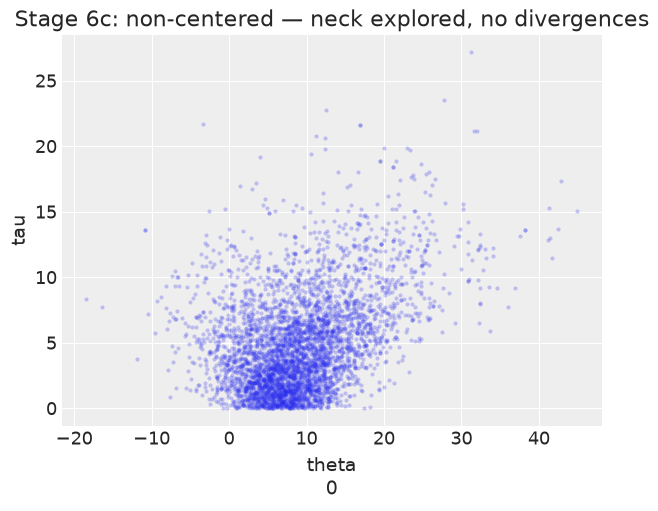

Divergences: centered 129  ->  non-centered 0


In [11]:
az.plot_pair(idata_nc, var_names=["theta", "tau"], coords={"theta_dim_0":[0]},
             divergences=True, figsize=(6,5),
             scatter_kwargs={"alpha":0.25})
plt.title("Stage 6c: non-centered — neck explored, no divergences"); plt.show()
print(f"Divergences: centered {div_c}  ->  non-centered {div_nc}")

## Stage 7 — Interpretation (non-centered model) + shrinkage
Report `mu`, `tau`, and the shrunk per-school `theta_j`. Note how each estimate is pulled toward `mu`.

mu  = 6.40  (94% HDI -1.28 to 14.35)
tau = 4.90  (94% HDI 0.01 to 11.75)

school  y_obs  theta_post  shrinkage
  A    28.0     9.06     +18.94
  B     8.0     6.79     +1.21
  C    -3.0     5.23     -8.23
  D     7.0     6.64     +0.36
  E    -1.0     4.62     -5.62
  F     1.0     5.45     -4.45
  G    18.0     8.83     +9.17
  H    12.0     6.88     +5.12


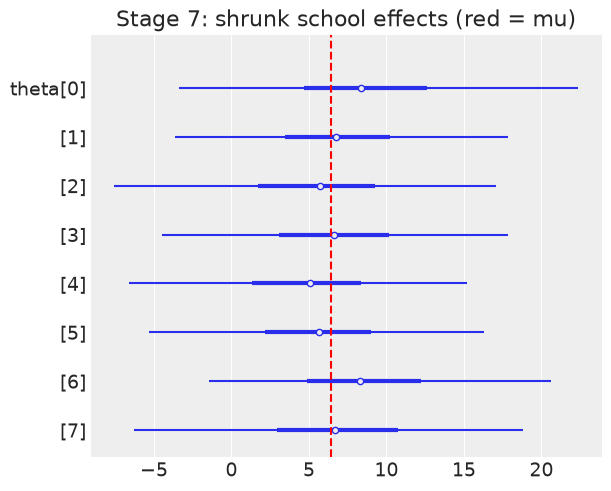

In [12]:
mu_m = idata_nc.posterior["mu"].mean().item()
tau_m = idata_nc.posterior["tau"].mean().item()
mu_hdi = az.hdi(idata_nc, var_names=["mu"], hdi_prob=0.94)["mu"].values
tau_hdi = az.hdi(idata_nc, var_names=["tau"], hdi_prob=0.94)["tau"].values
print(f"mu  = {mu_m:.2f}  (94% HDI {mu_hdi[0]:.2f} to {mu_hdi[1]:.2f})")
print(f"tau = {tau_m:.2f}  (94% HDI {tau_hdi[0]:.2f} to {tau_hdi[1]:.2f})")
theta_post = idata_nc.posterior["theta"].mean(dim=["chain","draw"]).values
print("\nschool  y_obs  theta_post  shrinkage")
for j in range(J):
    print(f"  {schools.school[j]}   {y[j]:5.1f}   {theta_post[j]:6.2f}     {y[j]-theta_post[j]:+.2f}")
az.plot_forest(idata_nc, var_names=["theta"], combined=True, hdi_prob=0.94)
plt.axvline(mu_m, color="r", ls="--"); plt.title("Stage 7: shrunk school effects (red = mu)"); plt.show()

## Stage 8 — Posterior predictive check
Replicate `y` and compare the spread (sd) and extremes to the observed estimates.

Sampling: [y]


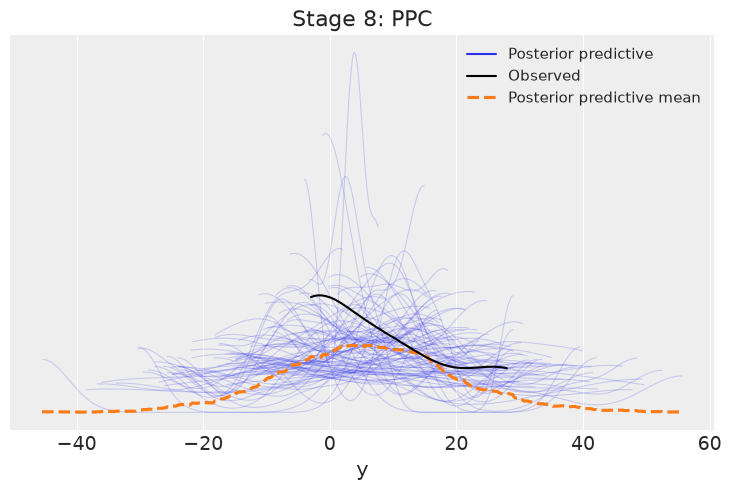

  mean: obs=   8.75  bayes-p=0.36
  sd  : obs=   9.77  bayes-p=0.74
  min : obs=  -3.00  bayes-p=0.15
  max : obs=  28.00  bayes-p=0.41


In [13]:
with model_nc:
    idata_nc.extend(pm.sample_posterior_predictive(idata_nc, random_seed=RANDOM_SEED, progressbar=False))
az.plot_ppc(idata_nc, num_pp_samples=100); plt.title("Stage 8: PPC"); plt.show()
ppc = idata_nc.posterior_predictive["y"].values.reshape(-1, J)
for name, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {name:4s}: obs={fn(y):7.2f}  bayes-p={(fn(ppc,axis=1)>=fn(y)).mean():.2f}")

## Stage 9 — Comparison: partial vs complete pooling (LOO)
The centered/non-centered choice is *computation*, not *model* — so for a genuine model comparison we
contrast **partial pooling** (the hierarchy) against **complete pooling** (`tau→0`, one shared effect).

In [14]:
with pm.Model() as model_pool:
    mu = pm.Normal("mu", 0, 10)
    pm.Normal("y", mu, sigma, observed=y)
    idata_pool = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                           random_seed=RANDOM_SEED, progressbar=False,
                           idata_kwargs={"log_likelihood": True})
cmp = az.compare({"partial_pooling": idata_nc, "complete_pooling": idata_pool})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata_nc.posterior.draw.size*idata_nc.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
kmax = az.loo(idata_nc, pointwise=True).pareto_k.values.max()
print(f"\nmax Pareto k-hat (partial): {kmax:.2f} | threshold {thr:.2f}")
ed, dse = cmp['elpd_diff'].iloc[1], cmp['dse'].iloc[1]
print(f"elpd_diff = {ed:.2f} +/- {dse:.2f}  ({ed/dse if dse>0 else float('nan'):.1f} SE)")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


                  rank   elpd_loo  elpd_diff      dse  weight
complete_pooling     0 -30.434436   0.000000  0.00000     1.0
partial_pooling      1 -30.730225   0.295789  0.17892     0.0

max Pareto k-hat (partial): 0.55 | threshold 0.70
elpd_diff = 0.30 +/- 0.18  (1.7 SE)


## Stage 10 — Power-scaling prior sensitivity (tau)
Reweight posterior draws by `prior^(alpha-1)` for the `tau ~ HalfNormal(10)` prior and check E[tau].

In [15]:
post = az.extract(idata_nc)
taud = post["tau"].values; mud = post["mu"].values
logprior = st.halfnorm.logpdf(taud, scale=10) + st.norm.logpdf(mud, 0, 10)
print("alpha   E[tau]   E[mu]")
for al in [0.8,1.0,1.25]:
    wgt = np.exp((al-1)*logprior); wgt/=wgt.sum()
    print(f" {al:4.2f}   {np.sum(wgt*taud):.3f}   {np.sum(wgt*mud):.3f}")

alpha   E[tau]   E[mu]
 0.80   5.115   6.617
 1.00   4.895   6.401
 1.25   4.663   6.154


## Stage 11 — SBC (Simulation-Based Calibration) on the NON-CENTERED model [Tier-3 required]
For 150 simulations: draw `(mu_t, tau_t)` from the priors, simulate `theta_j` and `y_j`, refit with a
**cheap** sampler (draws=400, tune=400, chains=2), and record the **rank** of the prior-draw `mu` among
the posterior draws. If the model + sampler are calibrated, the ranks are **uniform** (Talts et al. 2018;
Säilynoja et al. 2022). ∪/∩ shapes would signal miscalibration.

In [16]:
N_SBC = 150
ranks_mu = []
t0 = time.time()
with pm.Model() as sbc_model:
    y_data = pm.Data("y_data", y)
    mu_s = pm.Normal("mu", 0, 10)
    tau_s = pm.HalfNormal("tau", 10)
    z_s = pm.Normal("z", 0, 1, shape=J)
    theta_s = pm.Deterministic("theta", mu_s + tau_s*z_s)
    pm.Normal("y", theta_s, sigma, observed=y_data)
    for i in range(N_SBC):
        mu_tilde = rng.normal(0, 10)
        tau_tilde = abs(rng.normal(0, 10))
        theta_tilde = rng.normal(mu_tilde, tau_tilde, J)
        y_tilde = rng.normal(theta_tilde, sigma)
        pm.set_data({"y_data": y_tilde})
        idata_i = pm.sample(400, tune=400, chains=2, target_accept=0.9,
                            random_seed=int(rng.integers(1e6)), progressbar=False,
                            compute_convergence_checks=False)
        post_mu = idata_i.posterior["mu"].values.ravel()
        ranks_mu.append(int((post_mu < mu_tilde).sum()))
ranks_mu = np.array(ranks_mu)
L = idata_i.posterior.draw.size*idata_i.posterior.chain.size      # 800 posterior draws
print(f"SBC done: {N_SBC} sims in {time.time()-t0:.0f}s | rank range 0..{L}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, tau, z]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 2 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, tau, z]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 2 seconds.


SBC done: 150 sims in 347s | rank range 0..800


## Stage 11b — SBC rank histogram + uniformity test

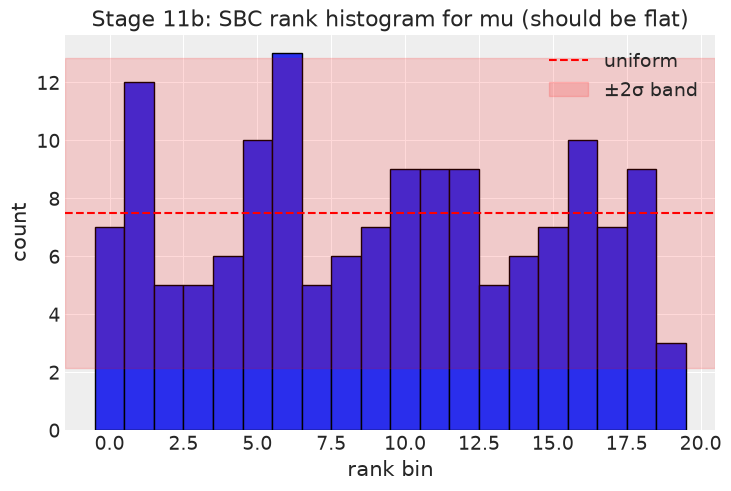

chi-square = 16.7, df = 19, p-value = 0.612
Uniform (calibrated)
all bins within +/-2sigma band: False


In [17]:
nbins = 20
counts, edges = np.histogram(ranks_mu, bins=nbins, range=(0, L+1))
expected = N_SBC/nbins
band = 2*np.sqrt(expected*(1-1/nbins))
chi2 = ((counts-expected)**2/expected).sum()
pval = st.chi2.sf(chi2, nbins-1)
plt.bar(range(nbins), counts, width=1.0, edgecolor="k")
plt.axhline(expected, color="r", ls="--", label="uniform")
plt.axhspan(expected-band, expected+band, color="r", alpha=.15, label="±2σ band")
plt.title("Stage 11b: SBC rank histogram for mu (should be flat)")
plt.xlabel("rank bin"); plt.ylabel("count"); plt.legend(); plt.show()
print(f"chi-square = {chi2:.1f}, df = {nbins-1}, p-value = {pval:.3f}")
print("Uniform (calibrated)" if pval > 0.05 else "NOT uniform — investigate")
print(f"all bins within +/-2sigma band: {bool(np.all(np.abs(counts-expected)<=band))}")

## Stage 12 — Decision & save

**Headline:** *the eight-schools coaching effect is small and uncertain (`mu` ≈ 4–8 points) with large
between-school SD uncertainty (`tau` poorly identified from 8 schools). The* **centered** *parameterization
fails with many divergences in the funnel; the* **non-centered** *form fixes it (0 divergences, ESS up),
and SBC confirms the fixed sampler is calibrated.*

In [18]:
os.makedirs("report", exist_ok=True)
idata_nc.to_netcdf("report/P11_idata.nc")
print("saved report/P11_idata.nc")
print(f"SUMMARY: centered div={div_c} -> non-centered div={div_nc}; "
      f"mu={mu_m:.2f}, tau={tau_m:.2f}; SBC p={pval:.3f}")

saved report/P11_idata.nc
SUMMARY: centered div=129 -> non-centered div=0; mu=6.40, tau=4.90; SBC p=0.612


## Exercises
1. Run SBC on **`tau`** instead of `mu`. Is the rank histogram still flat? (tau is hard to identify with J=8.)
2. Raise the centered model's `target_accept` to 0.99. Do the divergences disappear, and at what cost in speed?
3. Add a 9th school with a tiny SE. How does its `theta` shrink compared with the high-SE schools?